In [1]:
%load_ext autoreload
%autoreload 2

# !export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

In [2]:
import os
os.chdir('D:/thesis_code/keypoint_matcher')

from config import config
from utils import logger

import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F

config.log_level = 'TRACE'

# torch.set_float32_matmul_precision('medium')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# torch.cuda.empty_cache()

# Check Data Module

In [3]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.setup(stage='fit')
dl = dm.train_dataloader()

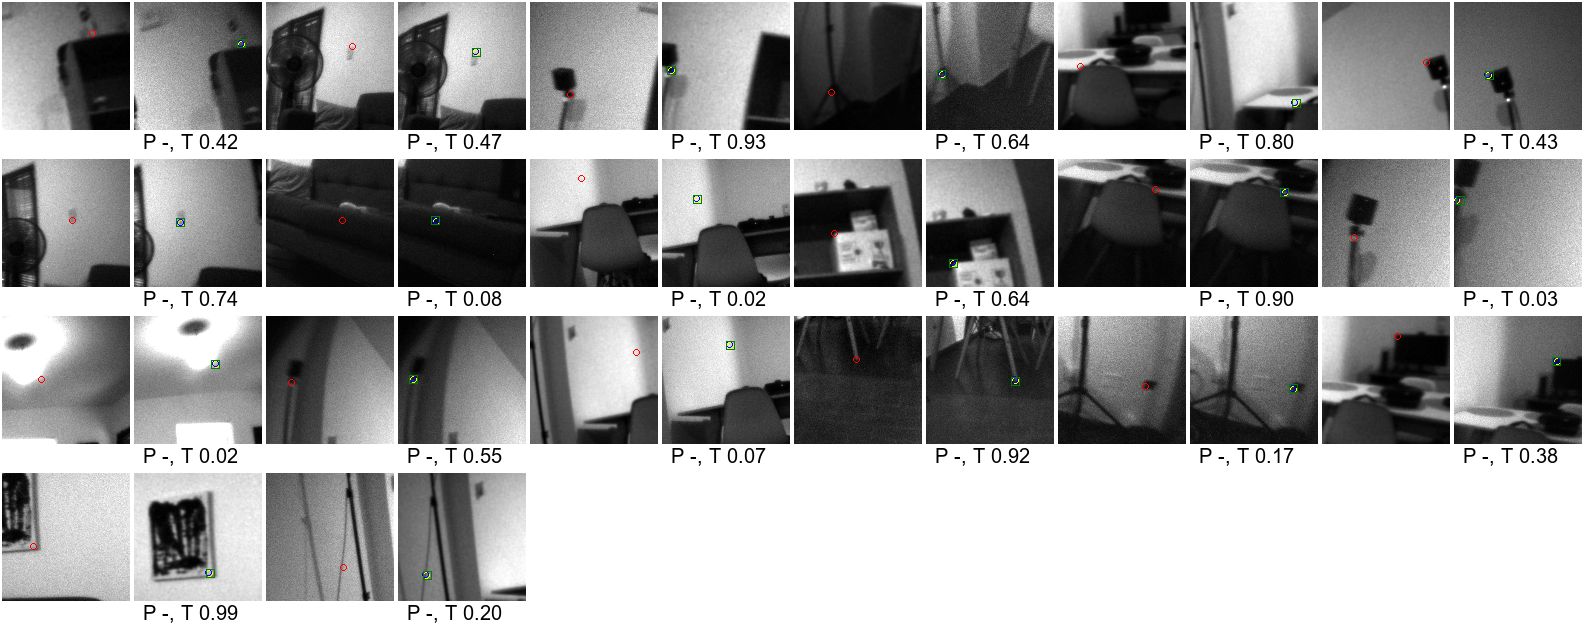

In [4]:
batch = next(iter(dl))
ref_patches, references, tar_patches, targets, estimates, confidences = batch

# ref_patches = ref_patches.to(device)
# tar_patches = tar_patches.to(device)
# references = references.to(device)
# estimates = estimates.to(device)

# print(f'{ref_keypoints[:6]=}')
# print(f'{tar_keypoints[:6]=}')

count = 24 * 2

from utils import show_batch
show_batch(
    ref_patches, tar_patches,
    references, estimates, targets,

    confidences_true=confidences,
    estimates=estimates,
    
    limit_count=count, 

    n_columns=6,
    just_gt=False,
)

# Light

In [5]:
# torch.cuda.empty_cache()

from src import Light
light = Light()

from utils import count_params
num = count_params(light.model)
print(f"{num:,}")

12,428,778


In [6]:
# torch.cuda.empty_cache()

target_coords = light(
    ref_patches, 
    tar_patches, 
    references,
    estimates,
)

print(f'{target_coords.shape=}')

target_coords.shape=torch.Size([20, 2])
